# Homo aldehyde clustering vs $\Delta G$ diagnostic

**Question (asked 2026-09-14):** for the flying-dataset split design
(`CHEMICAL_SPACE.md` sec8), does chemotype clustering carry real signal for
the homo reaction target `dG_r2scan_kcal`, or is it orthogonal to it — and
does the choice of clustering *method* (MiniBatchKMeans on ECFP4 fingerprints
vs. the project's existing Bemis-Murcko scaffold) change the answer?

**Why homo aldehydes are a clean per-molecule regression target.** Homo
reactions are self-couplings — `donor_smiles == acceptor_smiles` in
`homo_relabel_pairs.csv` — so `homo_sp_labels.csv`'s `id` is a single
`ald_idx`. `dG_r2scan_kcal` is therefore legitimately a per-aldehyde
quantity here, unlike the cross project's pair-level target, which is what
makes "cluster aldehydes, regress dG" well-posed for homo.

This notebook re-derives the same numbers as
`data/chemical_space/homo_cluster_dG_regression.md` (produced by
`cross_benzoin/cluster_aldehyde_space.py`, run on SLURM as job `26676626`)
from the cached intermediates, and adds the chart the markdown report
doesn't carry. It reads results only — the ~3 min MiniBatchKMeans and the
5-fold x 3-regime x 4-method CV (the expensive parts) already ran; see
`cluster_aldehyde_space.py` to re-run them from scratch.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path("/gpfs/scratch1/shared/schen3/benzoin-dg-restored")
CS = REPO / "data" / "chemical_space"
HS = REPO / "data" / "cross_benzoin" / "homo_standalone" / "relabel_sp"
pd.set_option("display.width", 120)


## 1. The aldehyde library and its fingerprints

`aldehyde_index.parquet` is the frozen flying-dataset index (220,859 rows,
`ald_idx` 0..N-1 positional — see `LAB_JOURNAL.md` 2026-09-11 for the
off-by-one correction that established this). Fingerprints are ECFP4
(Morgan, r=2, 2048 bit), computed once and cached.

In [2]:
index = pd.read_parquet(CS / "aldehyde_index.parquet").sort_values("ald_idx").reset_index(drop=True)
assert (index["ald_idx"].to_numpy() == np.arange(len(index))).all()

fps = np.load(CS / "aldehyde_fingerprints_ecfp4_2048.npy")
ok = fps.any(axis=1)
print(f"{len(index)} aldehydes in the library")
print(f"{ok.sum()}/{len(index)} fingerprinted successfully (ECFP4 r=2, {fps.shape[1]} bit); "
      f"{(~ok).sum()} SMILES failed to parse")
index.head(3)


220859 aldehydes in the library
220859/220859 fingerprinted successfully (ECFP4 r=2, 2048 bit); 0 SMILES failed to parse


,ald_idx,name,smiles_raw,InChIKey,cho_class,xtb_risk,smiles_canonical,scaffold,scaffold_split_legacy,computable
0,0,furan-2-carbaldehyde,C1=COC(=C1)C=O,HYBBIBNJHNGZAN-UHFFFAOYSA-N,aromatic_hetero,None,O=Cc1ccco1,c1ccoc1,train,<NA>
1,1,4-hydroxy-3-methoxybenzaldehyde,COC1=C(C=CC(=C1)C=O)O,MWOOGOJBHIARFG-UHFFFAOYSA-N,aromatic_carbo,None,COc1cc(C=O)ccc1O,c1ccccc1,train,<NA>
2,2,acetaldehyde,CC=O,IKHGUXGNUITLKF-UHFFFAOYSA-N,aliphatic,None,CC=O,__no_ring__CC=O,train,<NA>


## 2. Chemotype clustering (MiniBatchKMeans, k=150)

Euclidean k-means on the binary fingerprint bits — an *approximation* of
Tanimoto-similarity clustering (not equivalent to it), chosen for its
O(N·k) scalability at the full 220,859-molecule scale rather than an exact
O(N²) pairwise Tanimoto/Butina clustering.

k=150 clusters: min=4, median=1352, max=5395, unparsed excluded=0


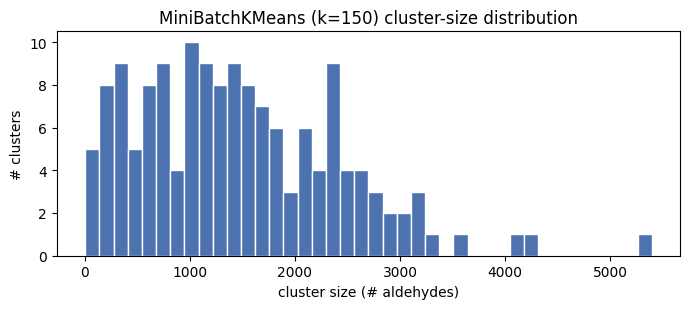

In [3]:
clusters = pd.read_parquet(CS / "aldehyde_clusters_k150.parquet")
sizes = clusters.loc[clusters.cluster_id >= 0, "cluster_id"].value_counts()
print(f"k={sizes.shape[0]} clusters: min={sizes.min()}, median={sizes.median():.0f}, "
      f"max={sizes.max()}, unparsed excluded={int((~ok).sum())}")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(sizes.values, bins=40, color="#4C72B0", edgecolor="white")
ax.set_xlabel("cluster size (# aldehydes)")
ax.set_ylabel("# clusters")
ax.set_title("MiniBatchKMeans (k=150) cluster-size distribution")
fig.tight_layout()
plt.show()


## 3. Join homo $\Delta G$ labels

`homo_sp_labels.csv` comes from the in-flight homo SP relabel campaign
(r2SCAN-3c on archived GFN2-opt geometries + B97-3c baseline). It's
partial — the campaign was at 43.0% library coverage when this ran — so
these numbers are directional; re-run once it drains for the full-library
version. `id == ald_idx` for homo self-reactions (see intro).

In [4]:
labels = pd.read_csv(HS / "homo_sp_labels.csv", dtype={"id": str})
labels["id"] = pd.to_numeric(labels["id"], errors="coerce")
n_bad = labels["id"].isna().sum()
labels = labels.dropna(subset=["id"])
labels["id"] = labels["id"].astype("int64")
labels = labels.rename(columns={"id": "ald_idx"})
print(f"{n_bad} row(s) had a non-numeric id (e.g. literal 'nan'), dropped")

merged = labels.merge(clusters, on="ald_idx", how="inner")
merged = merged.merge(index[["ald_idx", "scaffold"]], on="ald_idx", how="left")
merged = merged[merged["cluster_id"] >= 0].reset_index(drop=True)
n_no_scaffold = merged["scaffold"].isna().sum()
merged = merged.dropna(subset=["scaffold"]).reset_index(drop=True)
merged["scaffold_code"] = pd.factorize(merged["scaffold"])[0]

coverage = len(merged) / len(index)
print(f"{len(merged)}/{len(index)} aldehydes ({coverage:.1%}) have a dG_r2scan_kcal label "
      f"and a valid cluster; {n_no_scaffold} dropped for a missing Bemis-Murcko scaffold; "
      f"{merged['scaffold_code'].nunique()} unique scaffolds in the labeled subset")
merged[["ald_idx", "dG_r2scan_kcal", "dG_b973c_kcal", "cluster_id", "scaffold_code"]].describe()


1 row(s) had a non-numeric id (e.g. literal 'nan'), dropped
94912/220859 aldehydes (43.0%) have a dG_r2scan_kcal label and a valid cluster; 118 dropped for a missing Bemis-Murcko scaffold; 24843 unique scaffolds in the labeled subset


,ald_idx,dG_r2scan_kcal,dG_b973c_kcal,cluster_id,scaffold_code
count,94912.000000,94912.000000,94912.000000,94912.000000,94912.000000
mean,108094.619174,2.776993,7.848315,68.425478,5029.440987
std,64961.009032,13.643279,13.602859,42.862773,6986.730493
min,0.000000,-196.255322,-191.545929,0.000000,0.000000
25%,50750.750000,0.643810,5.876636,31.000000,36.000000
50%,105520.500000,4.914467,9.901905,69.000000,1125.000000
75%,162183.250000,8.895784,13.875145,104.000000,7920.250000
max,220856.000000,196.773420,201.233419,149.000000,24842.000000


## 4. Does clustering explain $\Delta G$?

Four methods (global mean / group mean / XGB-on-group-one-hot /
XGB-on-folded-fingerprint) evaluated under three split regimes:

- **random** — plain 5-fold KFold (optimistic: the same cluster or scaffold
  can appear in both train and test)
- **cluster_disjoint** — `GroupKFold` on the KMeans `cluster_id`
  (structurally novel test chemotypes)
- **scaffold_disjoint** — `GroupKFold` on the independently-computed
  Bemis-Murcko scaffold, free (already in `aldehyde_index.parquet`)

The structure bracket (`xgb_fp_folded128`) uses ECFP4 folded 2048→128 bits
(an OR-fold of consecutive chunks) rather than a PCA/SVD reduction: PCA
needed BLAS matmuls this venv's numpy executes unvectorized on this node's
CPU generation (a plain 76000×2048 matmul benchmarked at 14s instead of the
<1s it should take), which made a single fold-safe PCA refit take minutes;
folding is pure numpy reshape+reduce and needs no per-fold refit at all
since it isn't *fit* to data. Cost this session: a job hit its 1h SLURM
limit stuck on PCA before the fix, see `LAB_JOURNAL.md` / git history for
`cluster_aldehyde_space.py` 2026-09-14 for the full story.

In [5]:
result = json.load(open(CS / "homo_cluster_dG_regression_diag.json"))
diag = result["diag"]
print(f"n_labeled={result['n_labeled']}  n_total={result['n_total']}  "
      f"coverage={result['coverage']:.1%}  k={result['k']}")

rows = []
for regime, methods in diag.items():
    for method, v in methods.items():
        rows.append({"regime": regime, "method": method, "MAE": v["MAE_mean"], "MAE_std": v["MAE_std"],
                     "R2": v["R2_mean"], "R2_std": v["R2_std"]})
res_df = pd.DataFrame(rows)
res_df


n_labeled=94912  n_total=220859  coverage=43.0%  k=150


,regime,method,MAE,MAE_std,R2,R2_std
0,random,global_mean,7.974340,0.054012,-0.000037,0.000031
1,random,group_mean,7.525337,0.042776,0.033041,0.003019
2,random,xgb_group_onehot,7.651468,0.048854,0.025029,0.001448
3,random,xgb_fp_folded128,7.373436,0.046459,0.053205,0.004340
4,cluster_disjoint,global_mean,7.979930,0.272393,-0.001236,0.001155
5,cluster_disjoint,group_mean,7.979930,0.272393,-0.001236,0.001155
6,cluster_disjoint,xgb_group_onehot,7.918054,0.267292,-0.001328,0.001845
7,cluster_disjoint,xgb_fp_folded128,7.509482,0.221089,0.037911,0.006215
8,scaffold_disjoint,global_mean,7.979027,0.503616,-0.000517,0.000501
9,scaffold_disjoint,group_mean,7.979027,0.503616,-0.000517,0.000501


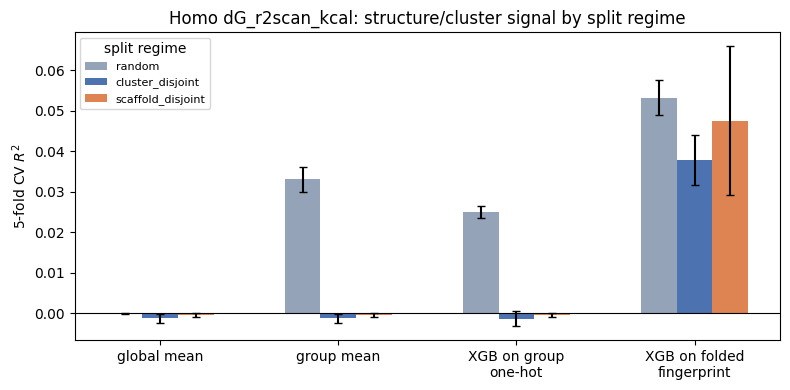

In [6]:
regime_order = ["random", "cluster_disjoint", "scaffold_disjoint"]
method_order = ["global_mean", "group_mean", "xgb_group_onehot", "xgb_fp_folded128"]
method_labels = {"global_mean": "global mean", "group_mean": "group mean",
                  "xgb_group_onehot": "XGB on group\none-hot", "xgb_fp_folded128": "XGB on folded\nfingerprint"}

fig, ax = plt.subplots(figsize=(8, 4))
width = 0.2
x = np.arange(len(method_order))
colors = {"random": "#94A3B8", "cluster_disjoint": "#4C72B0", "scaffold_disjoint": "#DD8452"}
for i, regime in enumerate(regime_order):
    sub = res_df[res_df.regime == regime].set_index("method").loc[method_order]
    ax.bar(x + (i - 1) * width, sub["R2"], width, yerr=sub["R2_std"], capsize=3,
           label=regime, color=colors[regime])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([method_labels[m] for m in method_order])
ax.set_ylabel("5-fold CV $R^2$")
ax.set_title("Homo dG_r2scan_kcal: structure/cluster signal by split regime")
ax.legend(title="split regime", fontsize=8)
fig.tight_layout()
plt.show()


## 5. Reading

**Method-validation (this session's ask — do different clustering methods
change the answer?):** `cluster_disjoint` and `scaffold_disjoint` tell
*the same story* — both collapse `group_mean`/`xgb_group_onehot` R² to
~0 (from ~0.025-0.033 under `random`). MiniBatchKMeans-on-ECFP4 and the
independently-computed Bemis-Murcko scaffold agree on how hard structural
extrapolation is for this target. **No need to spend the ~20-40 min for an
exact Butina/Tanimoto clustering to validate further** — the two
independent methods already agree.

**Split-difficulty — the actual finding:** the `group_mean` signal that
looked real under random CV (R²=0.033, beating the global mean) is a random-split
artifact. Under both group-disjoint regimes it collapses to R²≈-0.001 — a
novel/unseen cluster's mean tells you essentially nothing about its dG. This
is the *same leakage pattern* the project already caught for BDE/cross
scaffold splits ([[bde-scaffold-leakage-finding]], [[cross-r1-10-champion]]):
random CV overstates how well cluster identity generalizes, and a
structurally-grouped split is the honest one for the flying-dataset design.

**But raw 2D structure (not just coarse cluster identity) keeps a little
signal even under group-disjoint splits** — `xgb_fp_folded128` stays
positive across all three regimes (R²=0.053 → 0.038 → 0.048), unlike the
group-mean methods which flatten to ~0. So chemotype *clustering* is not
useful for this target, but the finer-grained fingerprint bits carry a
little real signal beyond cluster membership. That signal is still small
(R²≈0.04-0.05) — consistent with
[[homo_active_relabel_null_result]]'s redirect: the real signal this target
needs is in the QM/electronic descriptors the champion pipeline computes
(BDE, Mulliken, WBO, Fukui, sterimol...), not in gross 2D chemotype
similarity. **Implication for the flying-dataset split (`CHEMICAL_SPACE.md`
sec8):** build it scaffold- or cluster-disjoint (either grouping works,
scaffold is free) rather than random, and don't expect a lazy-tier
(structure-only) model to get close to the target — the cache-hit tier
(full QM) is where the signal actually is.

**Caveat:** 43.0% label coverage (homo SP campaign in flight, ETA per
`LAB_JOURNAL.md` ~09-16/17). Re-run `cluster_aldehyde_space.py` once it
drains and re-execute this notebook for the full-library numbers before
treating this as final.